# Pharma Sales Exploration

This notebook is for inspecting the raw sales CSV files and understanding the time-series pattern before any forecasting model is trained.

Goals:
- load the CSV files from the data folder
- inspect the columns and date structure
- visualize overall sales by drug category over time
- identify whether strong seasonality is present


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data')
DATA_DIR.exists()


True

In [4]:
# Load the daily sales data
sales_daily = pd.read_csv(DATA_DIR / 'salesdaily.csv')

sales_daily.head()


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [5]:
# Inspect columns and types
sales_daily.info()


<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 214.0 KB


In [6]:
# Convert the date column into a proper datetime format
sales_daily['datum'] = pd.to_datetime(sales_daily['datum'], format='%m/%d/%Y')

# Keep the sales columns and sort by time
sales_daily = sales_daily[['datum'] + [c for c in sales_daily.columns if c not in ['datum', 'Year', 'Month', 'Hour', 'Weekday Name']]]
sales_daily = sales_daily.sort_values('datum').reset_index(drop=True)

sales_daily.head()


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0


In [8]:
# Create a long-form table for plotting
sales_long = sales_daily.melt(id_vars='datum', var_name='category', value_name='sales')

sales_long.head()


,datum,category,sales
0,2014-01-02,M01AB,0.0
1,2014-01-03,M01AB,8.0
2,2014-01-04,M01AB,2.0
3,2014-01-05,M01AB,4.0
4,2014-01-06,M01AB,5.0


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. CRITICAL FIX: Convert string dates to actual datetime objects
sales_daily['datum'] = pd.to_datetime(sales_daily['datum'])

# 2. Aggregate to monthly sales so trends and seasonality are easier to see
monthly = sales_daily.set_index('datum').resample('MS').sum()
monthly_smooth = monthly.rolling(3, min_periods=1).mean()

# 3. Focus on a few categories to reduce clutter
selected_categories = ['N02BE', 'N02BA', 'M01AB', 'N05B', 'R03', 'R06']

fig, ax = plt.subplots(figsize=(15, 6)) # Gives precise axis control

for category in selected_categories:
    ax.plot(monthly_smooth.index, monthly_smooth[category], label=category, linewidth=2)

# --- PROFESSIONAL X-AXIS FORMATTING ---
# Major ticks: Show the Year clearly at the start of each year
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('\n%Y')) # \n moves the year to a second line

# Minor ticks: Label every single month by its abbreviated name (Jan, Feb, etc.)
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))

# Style the labels so they look clean and don't overlap
plt.setp(ax.get_xminorticklabels(), rotation=90, fontsize=9, color='gray') 
plt.setp(ax.get_xmajorticklabels(), fontsize=11, weight='bold', color='black') 

# Add subtle grid lines for both months and years to make reading patterns easy
ax.grid(True, which='minor', color='gainsboro', linestyle=':', linewidth=0.5)
ax.grid(True, which='major', color='darkgray', linestyle='--', linewidth=0.7)
# -------------------------------------

plt.title('Monthly Sales for Major Categories (3-Month Rolling Average)', fontsize=14, pad=15)
plt.ylabel('Sales Units', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
from prophet import Prophet

# 1. Aggregate daily data to monthly totals
# Assuming your daily dataframe is named 'sales_daily' and has a 'datum' column
monthly = sales_daily.set_index('datum').resample('MS').sum().reset_index()

# 2. Define categories and setup storage
categories = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
all_forecasts = {}
models = {}

# Define the train/validation cutoff
# Leaving the last 12 months for validation is typical if data goes up to mid-2019
train_end = '2018-06-30' 

print("Starting per-category training loop...")

# 3. Loop over categories
for cat in categories:
    print(f"Training model for category: {cat}...")
    
    # Prepare DataFrame for Prophet (requires columns 'ds' and 'y')
    df_cat = monthly[['datum', cat]].rename(columns={'datum': 'ds', cat: 'y'})
    
    # Split into train and validation sets
    train_df = df_cat[df_cat['ds'] <= train_end]
    val_df = df_cat[df_cat['ds'] > train_end]
    
    # Initialize and fit the Prophet model
    # Since data is monthly, we explicitly disable weekly and daily seasonality
    model = Prophet(
        yearly_seasonality=True, 
        weekly_seasonality=False, 
        daily_seasonality=False
    )
    model.fit(train_df)
    
    # Forecast the next 12 months (periods=12, freq='MS' for Monthly Start)
    future = model.make_future_dataframe(periods=12, freq='MS')
    forecast = model.predict(future)
    
    # Store the results for later evaluation
    models[cat] = model
    all_forecasts[cat] = {
        'forecast': forecast,
        'train_actuals': train_df,
        'val_actuals': val_df
    }

print("Loop completed successfully!")

c:\Users\Nureen\Desktop\All\MediTrack\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Starting per-category training loop...
Training model for category: M01AB...


21:18:56 - cmdstanpy - INFO - Chain [1] start processing
21:19:02 - cmdstanpy - INFO - Chain [1] done processing
21:19:03 - cmdstanpy - INFO - Chain [1] start processing


Training model for category: M01AE...


21:19:03 - cmdstanpy - INFO - Chain [1] done processing
21:19:03 - cmdstanpy - INFO - Chain [1] start processing


...

Training model for category: R03...


21:19:06 - cmdstanpy - INFO - Chain [1] done processing
21:19:06 - cmdstanpy - INFO - Chain [1] start processing


Training model for category: R06...


21:19:06 - cmdstanpy - INFO - Chain [1] done processing


Loop completed successfully!


           ds         yhat   yhat_lower   yhat_upper
54 2018-07-01   594.262613   389.860956   802.813130
55 2018-08-01   661.977175   468.327913   857.096431
56 2018-09-01   892.218904   702.198369  1101.363857
57 2018-10-01  1341.422938  1130.056273  1535.753955
58 2018-11-01   978.623004   787.488509  1181.977884
59 2018-12-01  1149.578656   962.461478  1356.471183
60 2019-01-01  1190.726992  1008.054002  1404.622926
61 2019-02-01  1068.232197   877.419214  1269.339724
62 2019-03-01   894.005204   672.657115  1090.835298
63 2019-04-01   765.937046   558.394258   981.361948
64 2019-05-01   607.510409   404.550995   792.517702
65 2019-06-01   601.716554   401.386810   802.107237


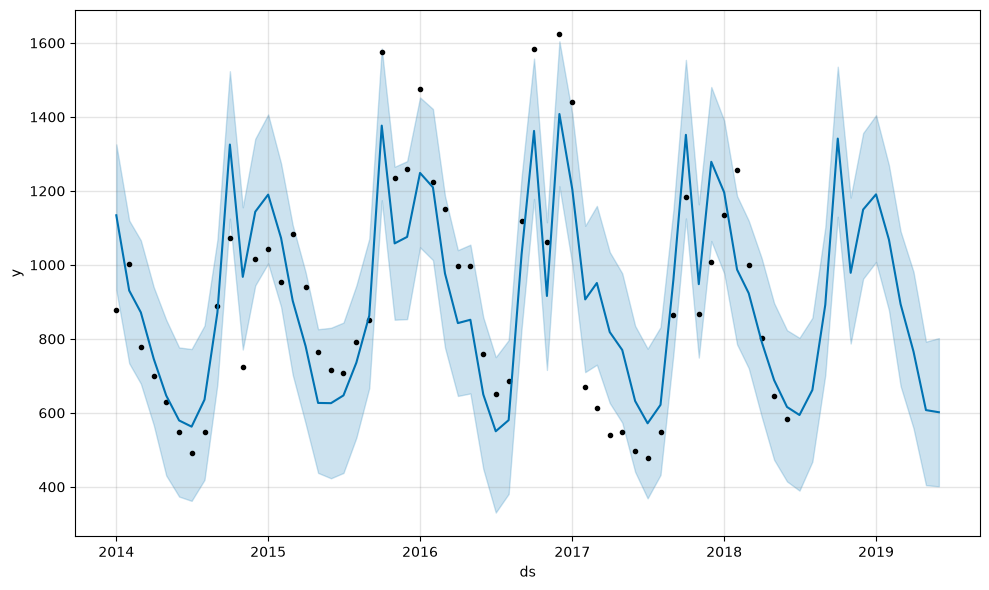

In [25]:
# Quick look at the N02BE forecast vs actuals
n02be_data = all_forecasts['N02BE']
forecast_df = n02be_data['forecast']

# Filter forecast to look at the validation period
validation_forecast = forecast_df[forecast_df['ds'] > train_end][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
print(validation_forecast)

# Optional: Plot it to visually inspect it
models['N02BE'].plot(forecast_df);